# France at World Cup 2022 — Passing Networks
**Calcio AC · CAC_post5**

One passing network per France game at Qatar 2022 (7 matches, group stage → final), built from StatsBomb open event data and exported as 1080×1350 images for Instagram / LinkedIn. Interactive version: [calcio-ac.github.io/CAC_post5](https://calcio-ac.github.io/CAC_post5/).

**Method**
- Each map shows the **11 France players with the most minutes in that match** — full game, extra time included, shootouts excluded.
- Completed passes between those 11, across the whole match.
- Node position = average location of a player's passes + receptions. Node size = passes involved in.
- Line width/darkness = passes between the two players (both directions combined, shown from 4+).
- Slide footer reports all France passes: attempted vs completed.


In [1]:
# !pip install statsbombpy pandas mplsoccer matplotlib
import warnings; warnings.filterwarnings('ignore')
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from mplsoccer import VerticalPitch
from statsbombpy import sb

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

# CAC brand
YELLOW, BLUE, RED, GREEN, BLACK = '#FFD166', '#0277B6', '#D90429', '#09D69F', '#000000'
plt.rcParams['font.family'] = 'Courier New'
os.makedirs('images', exist_ok=True)

## 1 · France's seven matches at Qatar 2022

In [2]:
if os.path.exists('matches.pkl'):
    matches = pd.read_pickle('matches.pkl')
else:
    matches = sb.matches(competition_id=43, season_id=106)  # FIFA World Cup 2022
    matches.to_pickle('matches.pkl')

france = matches[((matches.home_team == 'France') | (matches.away_team == 'France'))
                 & matches.competition.str.contains('World Cup')].sort_values('match_date')
france[['match_id', 'match_date', 'home_team', 'home_score', 'away_score', 'away_team', 'competition_stage']]

,match_id,match_date,home_team,home_score,away_score,away_team,competition_stage
94,3857279,2022-11-22,France,4,1,Australia,Group Stage
49,3857266,2022-11-26,France,2,1,Denmark,Group Stage
41,3857275,2022-11-30,Tunisia,1,0,France,Group Stage
81,3869152,2022-12-04,France,3,1,Poland,Round of 16
75,3869354,2022-12-10,England,1,2,France,Quarter-finals
76,3869552,2022-12-14,France,2,0,Morocco,Semi-finals
59,3869685,2022-12-18,Argentina,3,3,France,Final


In [3]:
# Events for all 7 matches (cached locally so re-runs are instant)
if os.path.exists('france_events.pkl'):
    events = {m: e for m, e in pd.read_pickle('france_events.pkl').items()
              if m in set(france.match_id)}
else:
    events = {mid: sb.events(match_id=mid) for mid in france.match_id}
    pd.to_pickle(events, 'france_events.pkl')

{m: len(e) for m, e in events.items()}

{3857279: 3963,
 3857266: 3853,
 3857275: 3564,
 3869152: 3618,
 3869354: 3239,
 3869552: 3551,
 3869685: 4407}

## 2 · Build one network: the top XI by minutes, full match

In [4]:
def short_name(full, nick):
    if isinstance(nick, str) and nick:
        full = nick
    parts = full.split()
    return parts[-1].upper() if len(parts) > 1 else full.upper()


def mmss(s):
    m, sec = s.split(':')
    return int(m) + int(sec) / 60


def build_network(mid):
    """Nodes, edges and metadata for France's passing network in one match.

    The XI = the 11 France players with the most minutes in this match
    (union of their lineup position spans, capped at the match end).
    """
    e = events[mid]
    f = e[(e.team == 'France') & (e.period < 5)]          # shootouts excluded
    match_end = float(e[e.period < 5].minute.max() + 1)

    lineup = sb.lineups(match_id=mid)['France']
    nick = dict(zip(lineup.player_name, lineup.player_nickname))
    jersey = dict(zip(lineup.player_name, lineup.jersey_number))

    mins = {}
    for _, r in lineup.iterrows():
        if not r.positions:
            continue
        start = min(mmss(p['from']) for p in r.positions if p['from'])
        end = min(max(mmss(p['to']) if p['to'] else match_end for p in r.positions),
                  match_end)
        if end > start:
            mins[r.player_name] = end - start
    top11 = set(sorted(mins, key=mins.get, reverse=True)[:11])

    all_passes = f[f.type == 'Pass']
    attempted, completed = len(all_passes), int(all_passes.pass_outcome.isna().sum())

    p = all_passes[all_passes.pass_outcome.isna() & all_passes.pass_recipient.notna()]
    p = p[p.player.isin(top11) & p.pass_recipient.isin(top11)]

    locs = {}
    for _, r in p.iterrows():
        locs.setdefault(r.player, []).append(r.location)
        locs.setdefault(r.pass_recipient, []).append(r.pass_end_location)
    nodes = {pl: (np.mean([l[0] for l in L]),
                  np.mean([l[1] for l in L]),
                  (p.player == pl).sum() + (p.pass_recipient == pl).sum())
             for pl, L in locs.items()}

    pairs = p.groupby(['player', 'pass_recipient']).size().reset_index(name='n')
    pairs['key'] = pairs.apply(lambda r: tuple(sorted([r.player, r.pass_recipient])), axis=1)
    edges = pairs.groupby('key').n.sum().reset_index().sort_values('n', ascending=False)

    return dict(nodes=nodes, edges=edges, nick=nick, jersey=jersey,
                attempted=attempted, completed=completed, n_passes=len(p))


net = build_network(france.match_id.iloc[-1])  # the final
net['edges'].head(5)

,key,n
32,"(Dayotchanculle Upamecano, Raphaël Varane)",30
42,"(Jules Koundé, Raphaël Varane)",27
33,"(Dayotchanculle Upamecano, Theo Bernard Franço...",18
1,"(Adrien Rabiot, Aurélien Djani Tchouaméni)",17
19,"(Aurélien Djani Tchouaméni, Dayotchanculle Upa...",16


## 3 · Render in CAC style (1080×1350)

In [5]:
STROKE = [pe.withStroke(linewidth=4, foreground=YELLOW)]


def draw_match(mid, slide_no, total=9, dpi=200):
    row = france[france.match_id == mid].iloc[0]
    net = build_network(mid)
    nodes, edges = net['nodes'], net['edges']
    nick, jersey = net['nick'], net['jersey']

    if row.home_team == 'France':
        score = f"FRANCE {row.home_score}\u2013{row.away_score} {row.away_team.upper()}"
        opp = row.away_team
    else:
        score = f"{row.home_team.upper()} {row.home_score}\u2013{row.away_score} FRANCE"
        opp = row.home_team

    fig = plt.figure(figsize=(10.8, 13.5), dpi=dpi)
    fig.patch.set_facecolor(YELLOW)

    fig.text(0.06, 0.965, '> FRANCE_PASSING_NETWORKS // WC 2022',
             fontsize=17, fontweight='bold', color=BLACK)
    fig.text(0.06, 0.912, score, fontsize=40, fontweight='bold', color=BLACK)
    fig.text(0.06, 0.882, f"{row.competition_stage.upper()} \u00b7 {row.match_date}",
             fontsize=20, fontweight='bold', color=RED)
    a, b = edges.iloc[0].key
    top_link = (f"TOP LINK: {short_name(a, nick.get(a))} \u2194 "
                f"{short_name(b, nick.get(b))} ({edges.iloc[0].n})")
    fig.text(0.06, 0.856, top_link, fontsize=17, fontweight='bold', color=BLUE)

    ax = fig.add_axes([0.05, 0.085, 0.90, 0.75])
    pitch = VerticalPitch(pitch_type='statsbomb', pitch_color=YELLOW,
                          line_color=BLACK, linewidth=2.5)
    pitch.draw(ax=ax)

    max_n = edges.n.max()
    for _, ed in edges[edges.n >= 4].iterrows():
        p1, p2 = ed.key
        if p1 not in nodes or p2 not in nodes:
            continue
        x1, y1, _ = nodes[p1]; x2, y2, _ = nodes[p2]
        pitch.lines(x1, y1, x2, y2, lw=1 + (ed.n / max_n) * 11,
                    color=BLACK, alpha=0.22 + 0.62 * (ed.n / max_n), ax=ax, zorder=1)

    max_s = max(v[2] for v in nodes.values())
    for pl, (x, y, s) in nodes.items():
        size = 750 + 2400 * (s / max_s)
        pitch.scatter(x, y, s=size, color=BLUE, edgecolors=BLACK, linewidth=2.5,
                      ax=ax, zorder=3)
        pitch.annotate(str(jersey.get(pl, '')), xy=(x, y), ax=ax, ha='center',
                       va='center', fontsize=16, fontweight='bold', color='white', zorder=4)
        offset = 3.4 + 2.2 * (s / max_s)   # clear the circle before placing the name
        txt = pitch.annotate(short_name(pl, nick.get(pl)), xy=(x - offset, y), ax=ax,
                             ha='center', va='top', fontsize=15, fontweight='bold',
                             color=BLACK, zorder=5)
        txt.set_path_effects(STROKE)

    ax.annotate('ATTACK', xy=(0.985, 0.62), xytext=(0.985, 0.40),
                xycoords='axes fraction', ha='center', fontsize=14, fontweight='bold',
                color=RED, rotation=90, va='center',
                arrowprops=dict(arrowstyle='-|>', color=RED, lw=2.5))

    fig.text(0.06, 0.055,
             f"{net['completed']}/{net['attempted']} passes completed \u00b7 "
             f"map: top XI by minutes \u00b7 line = 4+",
             fontsize=15, fontweight='bold', color=BLACK)
    fig.text(0.06, 0.030, '@calcio.ac \u00b7 calcioac.com \u00b7 data: StatsBomb',
             fontsize=15, color=BLACK)
    fig.text(0.94, 0.030, f'[{slide_no}/{total}]', fontsize=15, fontweight='bold',
             color=RED, ha='right')

    fname = f"images/{slide_no:02d}_france_{opp.lower().replace(' ', '_')}.png"
    fig.savefig(fname, dpi=dpi, facecolor=YELLOW)
    plt.close(fig)
    return fname

## 4 · Cover + outro slides

In [6]:
def draw_cover(dpi=200):
    fig = plt.figure(figsize=(10.8, 13.5), dpi=dpi)
    fig.patch.set_facecolor(YELLOW)
    fig.text(0.06, 0.93, '> CAC_ANALYTICS // PIPELINE_05', fontsize=18,
             fontweight='bold', color=BLACK)
    fig.text(0.06, 0.80, 'SEVEN GAMES.', fontsize=58, fontweight='bold', color=BLACK)
    fig.text(0.06, 0.745, 'SEVEN NETWORKS.', fontsize=58, fontweight='bold', color=RED)
    fig.text(0.06, 0.675, 'France\u2019s road to the World Cup 2022 final,',
             fontsize=23, fontweight='bold', color=BLACK)
    fig.text(0.06, 0.648, 'one passing map per match.', fontsize=23,
             fontweight='bold', color=BLACK)

    # mini legend network
    ax = fig.add_axes([0.13, 0.13, 0.74, 0.44]); ax.axis('off')
    ax.set_xlim(0, 10); ax.set_ylim(0, 10)
    pts = {'A': (2.4, 7.4, 30), 'B': (6.8, 8.0, 16), 'C': (4.6, 3.6, 22)}
    links = [('A', 'B', 9), ('A', 'C', 16), ('B', 'C', 5)]
    for p1, p2, n in links:
        x1, y1, _ = pts[p1]; x2, y2, _ = pts[p2]
        ax.plot([x1, x2], [y1, y2], color=BLACK, lw=n * 0.8, alpha=0.45,
                solid_capstyle='round', zorder=1)
    for k, (x, y, s) in pts.items():
        ax.scatter(x, y, s=s * 130, color=BLUE, edgecolors=BLACK, linewidth=3, zorder=3)
    ax.annotate('node size =\npasses involved in', xy=(2.4, 7.4), xytext=(0.4, 9.4),
                fontsize=17, fontweight='bold', color=BLACK,
                arrowprops=dict(arrowstyle='->', color=BLACK, lw=2))
    ax.annotate('line width =\npasses between pair', xy=(3.5, 5.6), xytext=(6.0, 5.2),
                fontsize=17, fontweight='bold', color=BLACK,
                arrowprops=dict(arrowstyle='->', color=BLACK, lw=2))
    ax.annotate('position = avg location\n(top XI by minutes)', xy=(4.6, 3.6),
                xytext=(1.0, 1.2), fontsize=17, fontweight='bold', color=BLACK,
                arrowprops=dict(arrowstyle='->', color=BLACK, lw=2))

    fig.text(0.06, 0.055, 'How to read a passing network \u2192 swipe',
             fontsize=17, fontweight='bold', color=RED)
    fig.text(0.06, 0.030, '@calcio.ac \u00b7 calcioac.com \u00b7 data: StatsBomb',
             fontsize=15, color=BLACK)
    fig.text(0.94, 0.030, '[1/9]', fontsize=15, fontweight='bold', color=RED, ha='right')
    fig.savefig('images/01_cover.png', dpi=dpi, facecolor=YELLOW)
    plt.close(fig)


def draw_outro(dpi=200):
    fig = plt.figure(figsize=(10.8, 13.5), dpi=dpi)
    fig.patch.set_facecolor(YELLOW)
    fig.text(0.06, 0.93, '> METHODOLOGY // NOTES', fontsize=18, fontweight='bold',
             color=BLACK)
    fig.text(0.06, 0.84, 'HOW THESE WERE BUILT', fontsize=44, fontweight='bold',
             color=BLACK)
    lines = [
        ('DATA', 'StatsBomb open events, WC 2022.'),
        ('THE XI', 'The 11 France players with the most'),
        ('', 'minutes in each match. Full game,'),
        ('', 'extra time in, shootouts out.'),
        ('PASSES', 'Completed passes between those 11.'),
        ('', 'Lines drawn from 4+ combinations,'),
        ('', 'both directions summed.'),
        ('POSITION', 'Avg of where a player passed from'),
        ('', 'and received. Not a formation chart.'),
        ('TOTALS', 'Each slide: all France passes,'),
        ('', 'attempted vs completed.'),
    ]
    y = 0.77
    for tag, txt in lines:
        if tag:
            fig.text(0.06, y, tag, fontsize=20, fontweight='bold', color=RED)
        fig.text(0.26, y, txt, fontsize=20, fontweight='bold', color=BLACK)
        y -= 0.04
    fig.text(0.06, 0.26, 'Interactive + downloads:', fontsize=21, fontweight='bold',
             color=BLACK)
    fig.text(0.06, 0.225, 'calcio-ac.github.io/CAC_post5', fontsize=21,
             fontweight='bold', color=BLUE)
    fig.text(0.06, 0.13, 'FOLLOW @calcio.ac FOR THE NEXT PIPELINE.', fontsize=21,
             fontweight='bold', color=BLACK)
    fig.text(0.06, 0.030, '@calcio.ac \u00b7 calcioac.com \u00b7 data: StatsBomb',
             fontsize=15, color=BLACK)
    fig.text(0.94, 0.030, '[9/9]', fontsize=15, fontweight='bold', color=RED, ha='right')
    fig.savefig('images/09_methodology.png', dpi=dpi, facecolor=YELLOW)
    plt.close(fig)

## 5 · Generate all nine images

In [7]:
draw_cover()
files = [draw_match(mid, i + 2) for i, mid in enumerate(france.match_id)]
draw_outro()
files

['images/02_france_australia.png',
 'images/03_france_denmark.png',
 'images/04_france_tunisia.png',
 'images/05_france_poland.png',
 'images/06_france_england.png',
 'images/07_france_morocco.png',
 'images/08_france_argentina.png']

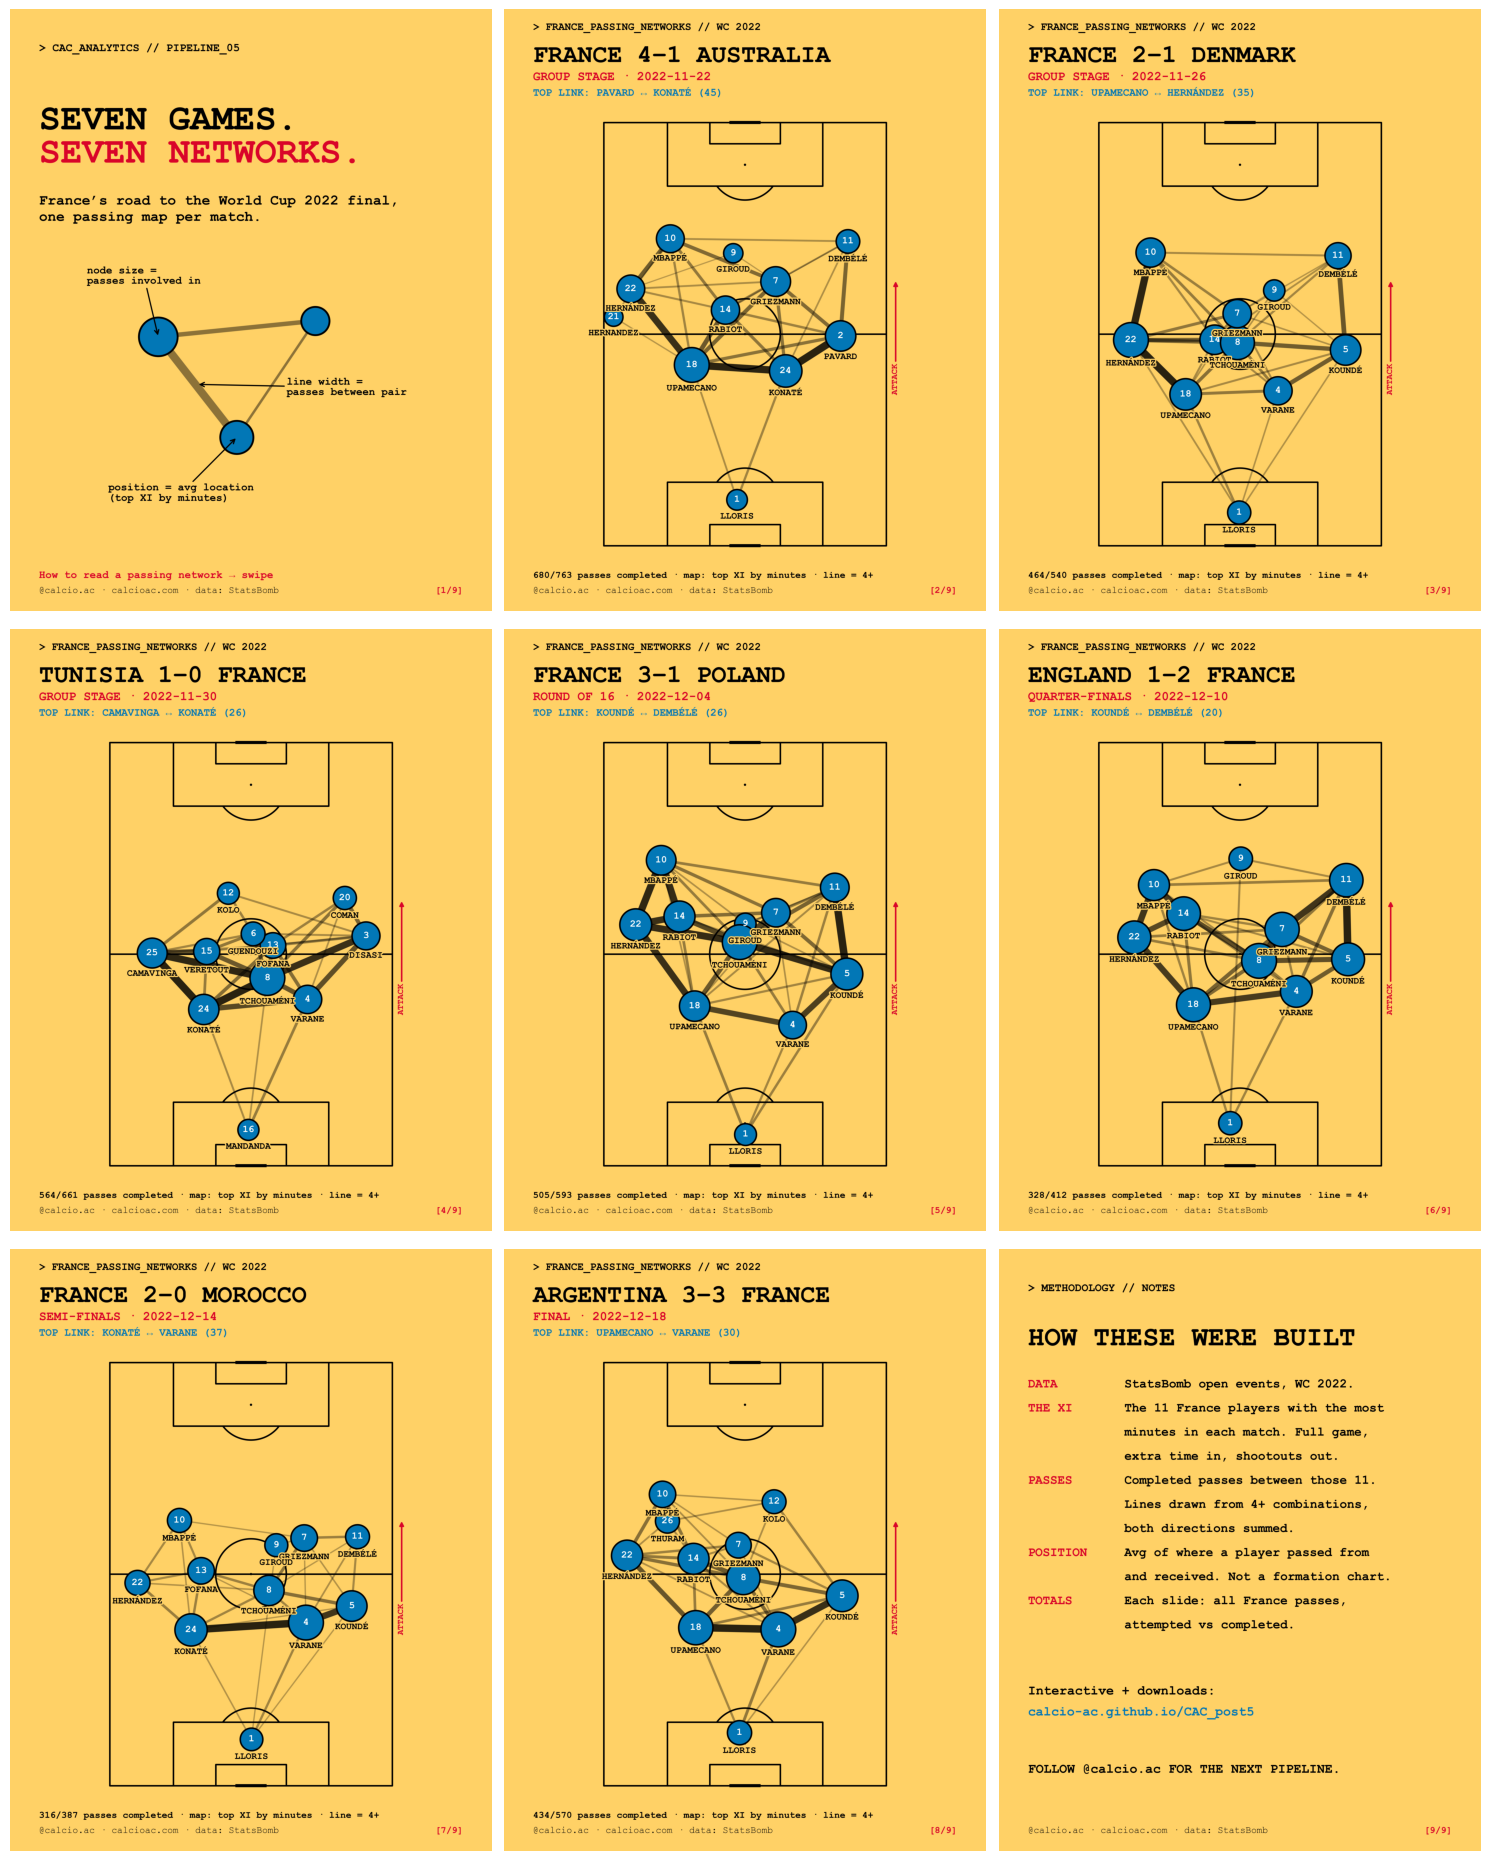

In [8]:
# preview the full carousel inline
from matplotlib.image import imread
import glob

paths = sorted(glob.glob('images/0*.png'))
fig, axes = plt.subplots(3, 3, figsize=(15, 18.75))
for ax, p in zip(axes.flat, paths):
    ax.imshow(imread(p)); ax.axis('off')
plt.tight_layout(); plt.show()